# Week 1 Seminar

A/B experiment analysis

In [1]:
import glob
from collections import namedtuple

import pandas as pd
import numpy as np
import scipy.stats as ss

import matplotlib.pyplot as plt

pd.set_option("display.precision", 3)

%matplotlib inline

In [2]:
experiment = "PERSONALIZED"

In [3]:
data = pd.concat([
    pd.read_json(data_path, lines=True)
    for data_path
    in glob.glob("/Users/n.anokhin/Desktop/data/*/data.json")
])

data["treatment"] = data["experiments"].map(lambda experiments: experiments[experiment])

In [4]:
data

,message,timestamp,user,track,time,latency,recommendation,experiments,treatment
0,next,2025-09-02 19:20:10.938,1996,79,1.00,7.034e-03,8254.0,{'PERSONALIZED': 'T3'},T3
1,next,2025-09-02 19:20:10.942,3693,40,0.79,1.285e-03,38.0,{'PERSONALIZED': 'T2'},T2
2,next,2025-09-02 19:20:10.943,8830,1261,0.06,1.802e-04,1638.0,{'PERSONALIZED': 'T3'},T3
3,next,2025-09-02 19:20:10.945,8830,1638,0.06,1.543e-04,1486.0,{'PERSONALIZED': 'T3'},T3
4,next,2025-09-02 19:20:10.947,8830,1486,0.71,1.507e-04,1461.0,{'PERSONALIZED': 'T3'},T3
...,...,...,...,...,...,...,...,...,...
54031,last,2025-09-02 19:22:29.465,1064,3809,0.00,8.988e-05,NaN,{'PERSONALIZED': 'T1'},T1
54032,next,2025-09-02 19:22:29.473,8629,8683,0.71,3.040e-04,4141.0,{'PERSONALIZED': 'T2'},T2
54033,next,2025-09-02 19:22:29.476,8629,8683,0.00,2.937e-04,8686.0,{'PERSONALIZED': 'T2'},T2
54034,next,2025-09-02 19:22:29.487,962,1155,1.00,1.516e-04,8014.0,{'PERSONALIZED': 'T3'},T3


In [17]:
data[
    (data["treatment"] == "T2") & 
    (data["user"] == 3693)
].sort_values("timestamp")

,message,timestamp,user,track,time,latency,recommendation,experiments,treatment
0,next,2025-09-02 19:20:10.936,3693,34,1.00,4.291e-03,40.0,{'PERSONALIZED': 'T2'},T2
1,next,2025-09-02 19:20:10.942,3693,40,0.79,1.285e-03,38.0,{'PERSONALIZED': 'T2'},T2
3,next,2025-09-02 19:20:10.945,3693,38,0.61,4.845e-04,37.0,{'PERSONALIZED': 'T2'},T2
4,next,2025-09-02 19:20:10.947,3693,37,0.51,3.531e-04,32.0,{'PERSONALIZED': 'T2'},T2
5,next,2025-09-02 19:20:10.949,3693,32,0.36,5.004e-04,37.0,{'PERSONALIZED': 'T2'},T2
7,next,2025-09-02 19:20:10.951,3693,37,0.00,4.020e-04,36.0,{'PERSONALIZED': 'T2'},T2
8,next,2025-09-02 19:20:10.954,3693,36,0.26,4.680e-04,37.0,{'PERSONALIZED': 'T2'},T2
9,next,2025-09-02 19:20:10.956,3693,37,0.00,3.984e-04,37.0,{'PERSONALIZED': 'T2'},T2
10,last,2025-09-02 19:20:10.958,3693,37,0.00,8.011e-05,NaN,{'PERSONALIZED': 'T2'},T2
20030,next,2025-09-02 19:21:06.718,3693,62,1.00,4.935e-04,64.0,{'PERSONALIZED': 'T2'},T2


In [5]:
data.groupby("treatment").count()

,message,timestamp,user,track,time,latency,recommendation,experiments
treatment,,,,,,,,
C,66707,66707,66707,66707,66707,66707,59028,66707
T1,75965,75965,75965,75965,75965,75965,68317,75965
T2,57026,57026,57026,57026,57026,57026,49644,57026
T3,70482,70482,70482,70482,70482,70482,63191,70482


## Visualize sessions

In [6]:
Session = namedtuple("Session", ["timestamp", "tracks", "time", "latency"])

def sessionize(user_data):
    sessions = []
    session = None
    for _, row in user_data.sort_values("timestamp").iterrows():
        if session is None:
            session = Session(row["timestamp"], 0, 0, 0)
        
        session = session._replace(
            tracks = session.tracks + 1, 
            time = session.time + row["time"],
            latency = session.latency + row["latency"] * 1000,
        )
        
        if row["message"] == "last":
            sessions.append(session._asdict())
            session = None
    return sessions

In [7]:
sessions = (
    data
    .groupby(["user", "treatment"])
    .apply(sessionize)
    .explode()
    .apply(pd.Series)
)

/var/folders/vq/_5djr0p11jv95fzz1mx_9f480000gp/T/ipykernel_30798/2354129256.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data


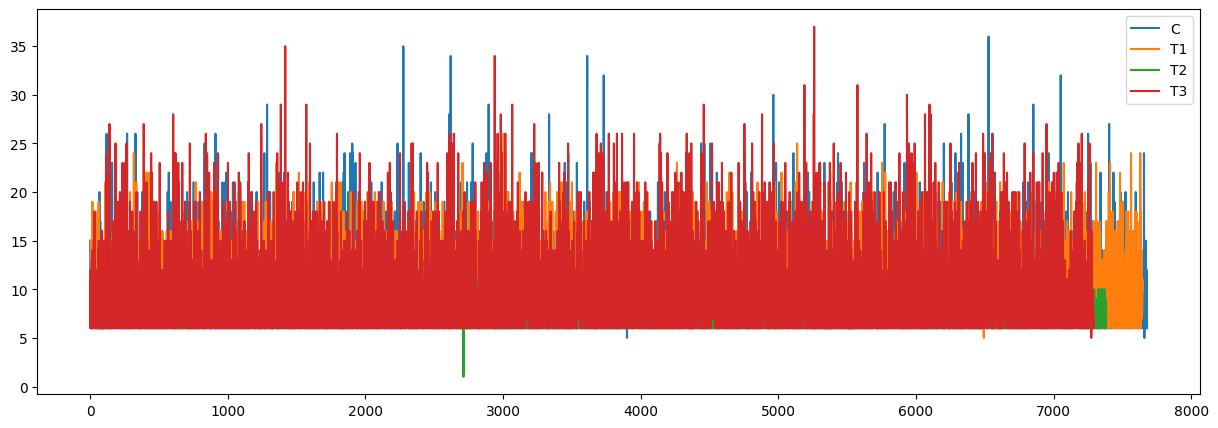

In [8]:
figure, ax = plt.subplots(figsize=(15, 5))
for treatment, treatment_sessions in sessions.groupby("treatment"):
    reindexed_treatment_sessions = treatment_sessions.sort_values("timestamp").reset_index()
    ax.plot(reindexed_treatment_sessions.index, reindexed_treatment_sessions["tracks"], label=treatment)
ax.legend()
pass

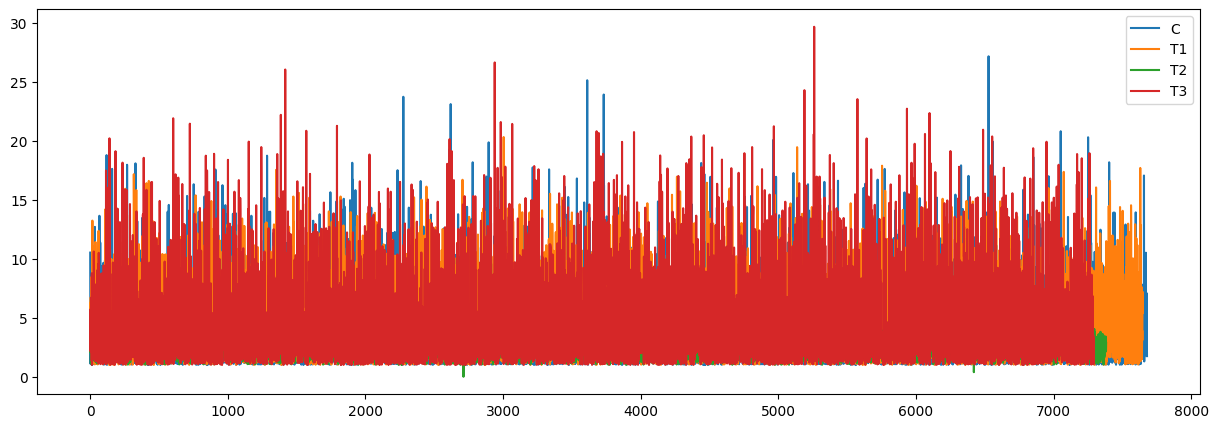

In [9]:
figure, ax = plt.subplots(figsize=(15, 5))
for treatment, treatment_sessions in sessions.groupby("treatment"):
    reindexed_treatment_sessions = treatment_sessions.sort_values("timestamp").reset_index()
    ax.plot(reindexed_treatment_sessions.index, reindexed_treatment_sessions["time"], label=treatment)
ax.legend()
pass

## Analyze the experiment

In [10]:
user_level_data = (
  sessions
    .reset_index()
    .groupby(["user", "treatment"])
    .agg(
        {
            "timestamp": "count",
            "tracks": "sum",
            "time": "sum",
            "latency": "sum"
        }
    )
)

user_level_data["sessions"] = user_level_data["timestamp"]
user_level_data["mean_request_latency"] = user_level_data["latency"] / user_level_data["tracks"]
user_level_data["mean_tracks_per_session"] = user_level_data["tracks"] / user_level_data["sessions"]
user_level_data["mean_time_per_session"] = user_level_data["time"] / user_level_data["sessions"]

metrics = [
    "time", 
    "sessions", 
    "mean_request_latency", 
    "mean_tracks_per_session", 
    "mean_time_per_session"
]

user_level_metrics = user_level_data[metrics].copy().reset_index()

In [11]:
treatment_level_metrics = (
    user_level_metrics
    .groupby("treatment")[metrics]
    .agg(["count", "mean", "var"])
)

In [12]:
def dof(n_0, n_1, s2_0, s2_1):
    numerator = (s2_0 / n_0 + s2_1 / n_1) * (s2_0 / n_0 + s2_1 / n_1)
    denominator = s2_0 * s2_0 / n_0 / n_0 / (n_0 - 1) + s2_1 * s2_1 / n_1 / n_1 / (n_1 - 1)
    return numerator / denominator


def ci(n_0, n_1, s2_0, s2_1, alpha=0.05):
    return ss.t.ppf(1 - alpha/2, dof(n_0, n_1, s2_0, s2_1)) * np.sqrt(s2_0 / n_0 + s2_1 / n_1)


effects = []

control = [data for treatment, data in treatment_level_metrics.iterrows() if treatment == "C"][0]

for treatment, row in treatment_level_metrics.iterrows():
    if treatment == "C":
        continue
    
    for metric in metrics:
        control_mean = control[metric]["mean"]
        treatment_mean = row[metric]["mean"]
        
        effect = treatment_mean - control_mean
        conf_int = ci(
            control[metric]["count"],
            row[metric]["count"],
            control[metric]["var"],
            row[metric]["var"],
        )
        effects.append({
            "treatment": treatment,
            "metric": metric,
            "control_mean": control_mean,
            "treatment_mean": treatment_mean,
            "effect": effect / control_mean * 100,
            "lower": (effect - conf_int) / control_mean * 100,
            "upper": (effect + conf_int) / control_mean * 100,
            "significant": (effect + conf_int) * (effect - conf_int) > 0
        })

In [13]:
def color(value):
    return 'color:red;' if value < 0 else 'color:green;'

def background(value):
    return 'color:white;background-color:green' if value else 'color:white;background-color:red'
        

(
    pd.DataFrame(effects)[[
        "treatment", 
        "metric",
        "effect", 
        "upper", 
        "lower", 
        "control_mean", 
        "treatment_mean",
        "significant"
    ]]
    .sort_values(["metric", "treatment"], ascending=False)
    .style
    .applymap(color, subset=["effect", "upper", "lower"])
    .applymap(background, subset=["significant"])
)

/var/folders/vq/_5djr0p11jv95fzz1mx_9f480000gp/T/ipykernel_30798/2520370983.py:9: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  pd.DataFrame(effects)[[


,treatment,metric,effect,upper,lower,control_mean,treatment_mean,significant
10,T3,time,22.888407,28.943870,16.832944,11.811730,14.515247,True
5,T2,time,-26.784248,-22.642433,-30.926063,11.811730,8.648047,True
0,T1,time,31.697999,37.290469,26.105530,11.811730,15.555813,True
11,T3,sessions,-2.622351,0.240421,-5.485122,3.194260,3.110495,False
6,T2,sessions,-0.601260,2.255934,-3.458454,3.194260,3.175054,False
1,T1,sessions,-1.225450,1.613200,-4.064100,3.194260,3.155116,False
13,T3,mean_tracks_per_session,11.247101,13.425326,9.068875,8.702757,9.681565,True
8,T2,mean_tracks_per_session,-11.196386,-9.768716,-12.624056,8.702757,7.728363,True
3,T1,mean_tracks_per_session,14.091871,15.997148,12.186594,8.702757,9.929139,True
14,T3,mean_time_per_session,26.374688,31.159402,21.589974,3.706519,4.684102,True
